# Frozen Python-150 exploratory analysis

## tl;dr

- DeepSeek V4 Flash: **99/150 (66.0%)** Functional Pass@1.
- Qwen3.5 and Qwen3.6: **59/150 (39.3%)** each, but they disagree on 40 task outcomes.
- GPT-OSS: **27/150 (18.0%)**.
- **42 tasks** are solved by no evaluated model; **11 tasks** are solved by all four.
- This is historical Python-150 evidence with evaluator-image and context-policy caveats, not the final Python-200′ leaderboard.

## Context & Methods

The notebook reruns the checked analysis module. Functional Pass@1 is the conjunction of build, Public, Hidden, and isolation gates. Wilson intervals use the 150-task denominator; paired model comparisons use exact McNemar tests; task-family intervals bootstrap tasks.

In [1]:
from pathlib import Path
import sys
REPORT_DIR = Path.cwd()
sys.path.insert(0, str(REPORT_DIR))
from analyze_python150 import run_analysis
outputs = run_analysis(write_notebook_file=False)
quality = outputs['quality']
tables = outputs['tables']
quality

{'rows': 600,
 'models': 4,
 'tasks': 150,
 'rows_per_model': {'DeepSeek V4 Flash': 150,
  'Qwen3.5 122B': 150,
  'Qwen3.6 35B': 150,
  'GPT-OSS 120B': 150},
 'duplicate_model_task_pairs': 0,
 'null_key_cells': 0,
 'evaluation_missing_rows': 12,
 'evaluation_missing_by_model': {'DeepSeek V4 Flash': 5,
  'GPT-OSS 120B': 3,
  'Qwen3.5 122B': 0,
  'Qwen3.6 35B': 4},
 'token_complete_rows': 600,
 'functional_pass_rows': 244,
 'pass_rows_with_rres': 244,
 'taxonomy_rows': 150,
 'taxonomy_unique_tasks': 150,
 'taxonomy_duplicate_tasks': 0,
 'taxonomy_join_coverage': 150,
 'context_violation_rows': 48,
 'context_violations_by_model': {'DeepSeek V4 Flash': 8,
  'GPT-OSS 120B': 0,
  'Qwen3.5 122B': 9,
  'Qwen3.6 35B': 31},
 'eligibility_caveat': 'Historical frozen Python-150 evidence only: evaluator image identity does not match the active paper freeze, and some runs violate the declared context allowance.'}

## Data

The source has 600 unique model-task rows, exactly 150 tasks per model, with no duplicate model-task keys.

In [2]:
tables['model_summary'][['model','functional_pass','assigned','functional_rate','wilson_low','wilson_high','context_violations','evaluation_missing']]

,model,functional_pass,assigned,functional_rate,wilson_low,wilson_high,context_violations,evaluation_missing
0,DeepSeek V4 Flash,99,150,0.660000,0.581043,0.730967,8,5
1,Qwen3.5 122B,59,150,0.393333,0.318760,0.473234,9,0
2,Qwen3.6 35B,59,150,0.393333,0.318760,0.473234,31,4
3,GPT-OSS 120B,27,150,0.180000,0.126758,0.249223,0,3


## Results

### Functional capability and paired comparisons

In [3]:
tables['pairwise_comparisons']

,left,right,pair,both_pass,left_only,right_only,both_fail,discordant,left_advantage,mcnemar_exact_p
0,DeepSeek V4 Flash,Qwen3.5 122B,DeepSeek vs Qwen3.5,53,46,6,45,52,40,1.032582e-08
1,DeepSeek V4 Flash,Qwen3.6 35B,DeepSeek vs Qwen3.6,53,46,6,45,52,40,1.032582e-08
2,DeepSeek V4 Flash,GPT-OSS 120B,DeepSeek vs GPT-OSS,24,75,3,48,78,72,5.238237e-19
3,Qwen3.5 122B,Qwen3.6 35B,Qwen3.5 vs Qwen3.6,39,20,20,71,40,0,1.000000e+00
4,Qwen3.5 122B,GPT-OSS 120B,Qwen3.5 vs GPT-OSS,18,41,9,82,50,32,5.614100e-06
5,Qwen3.6 35B,GPT-OSS 120B,Qwen3.6 vs GPT-OSS,17,42,10,81,52,32,9.063272e-06


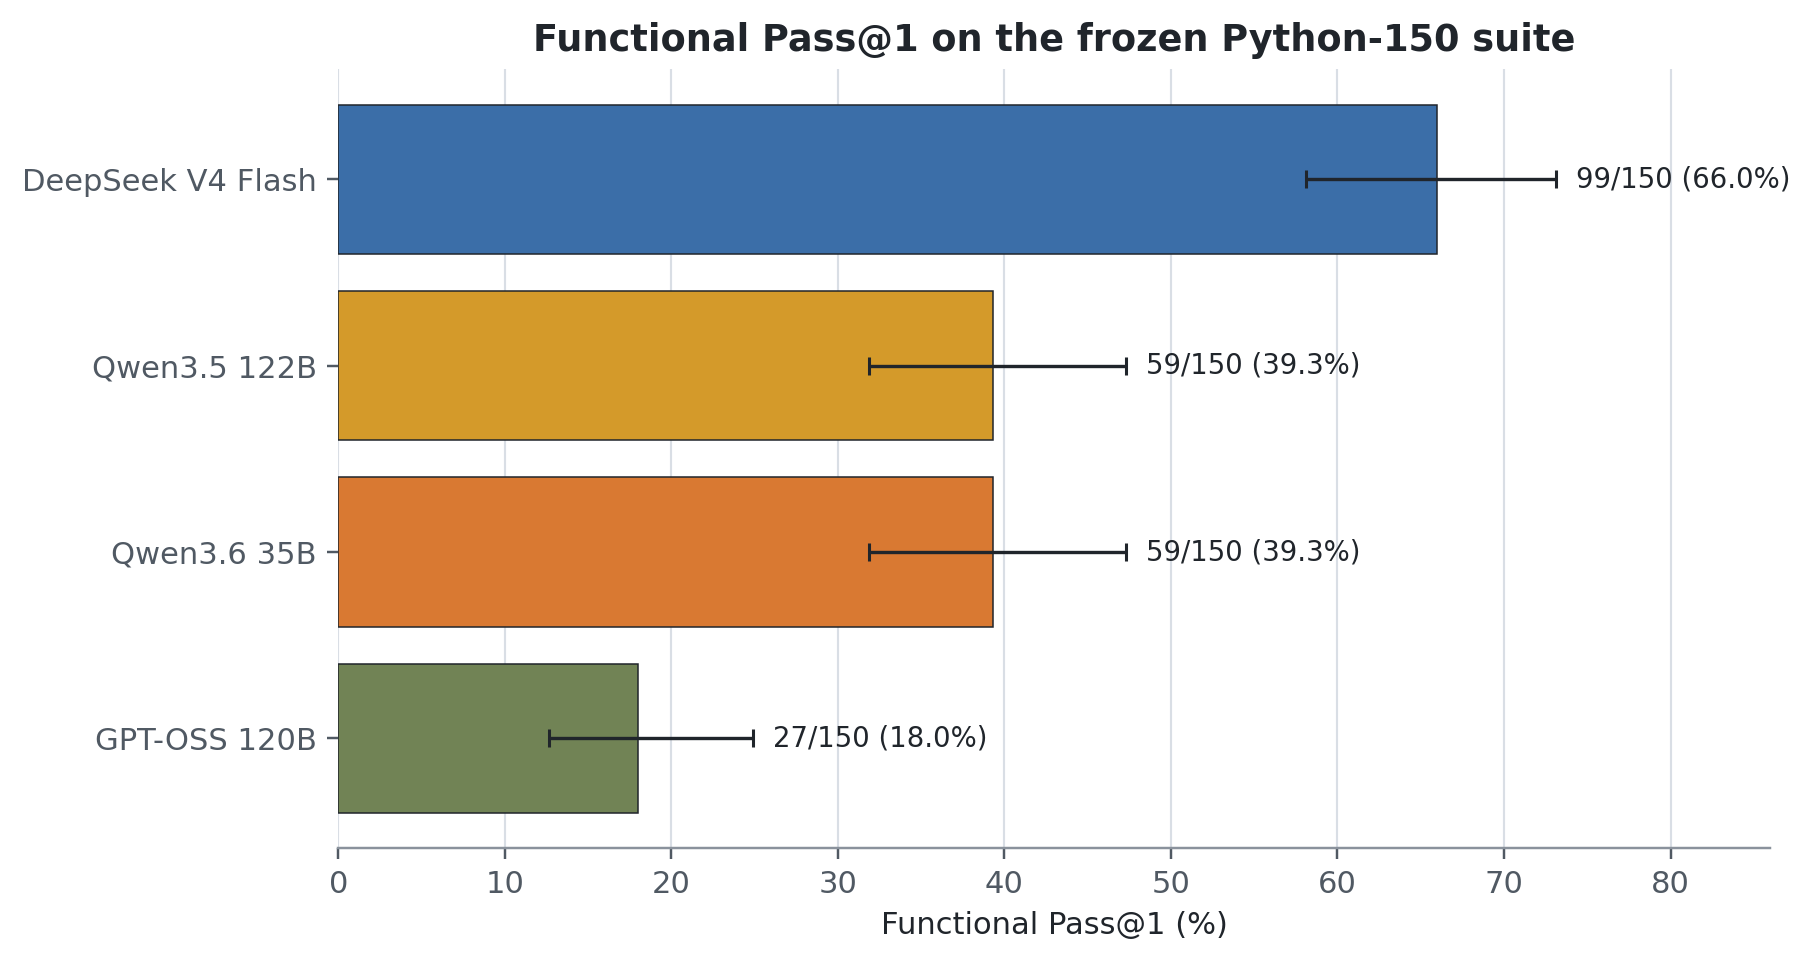

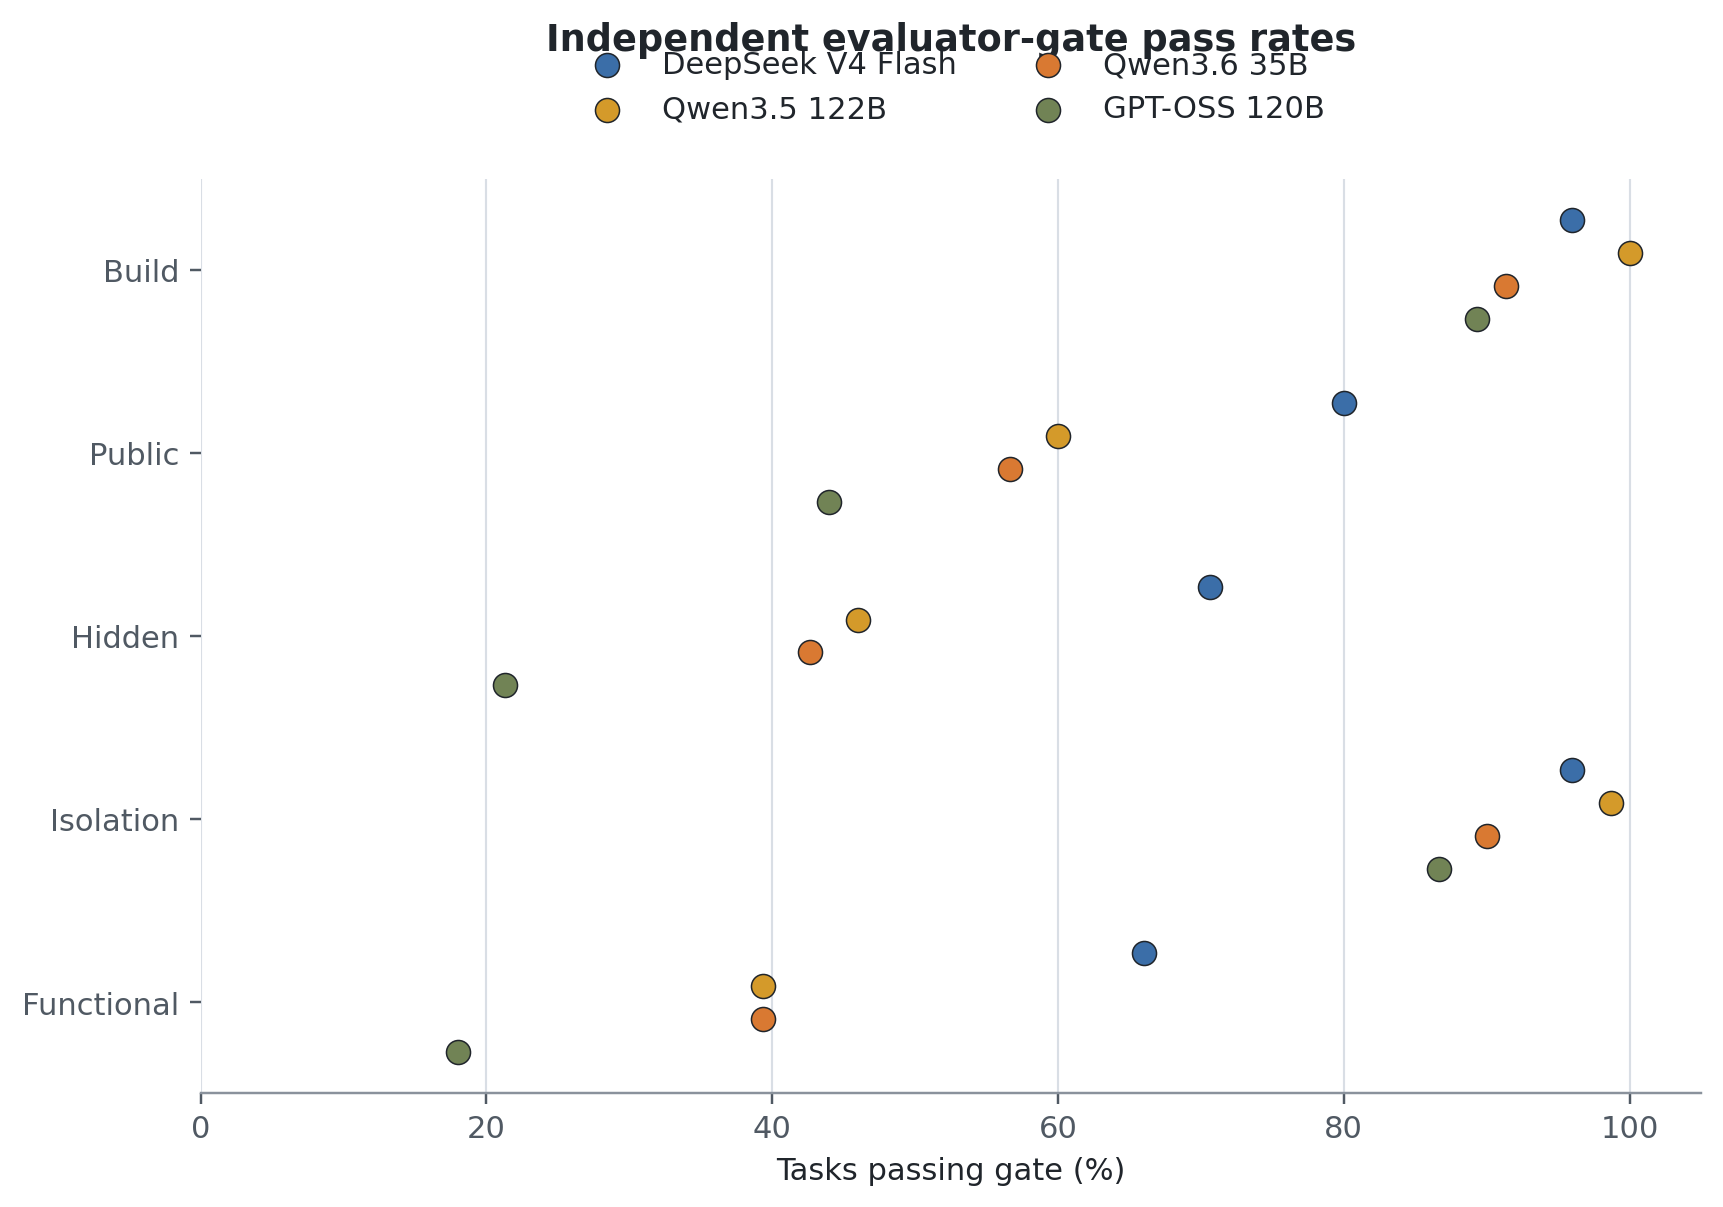

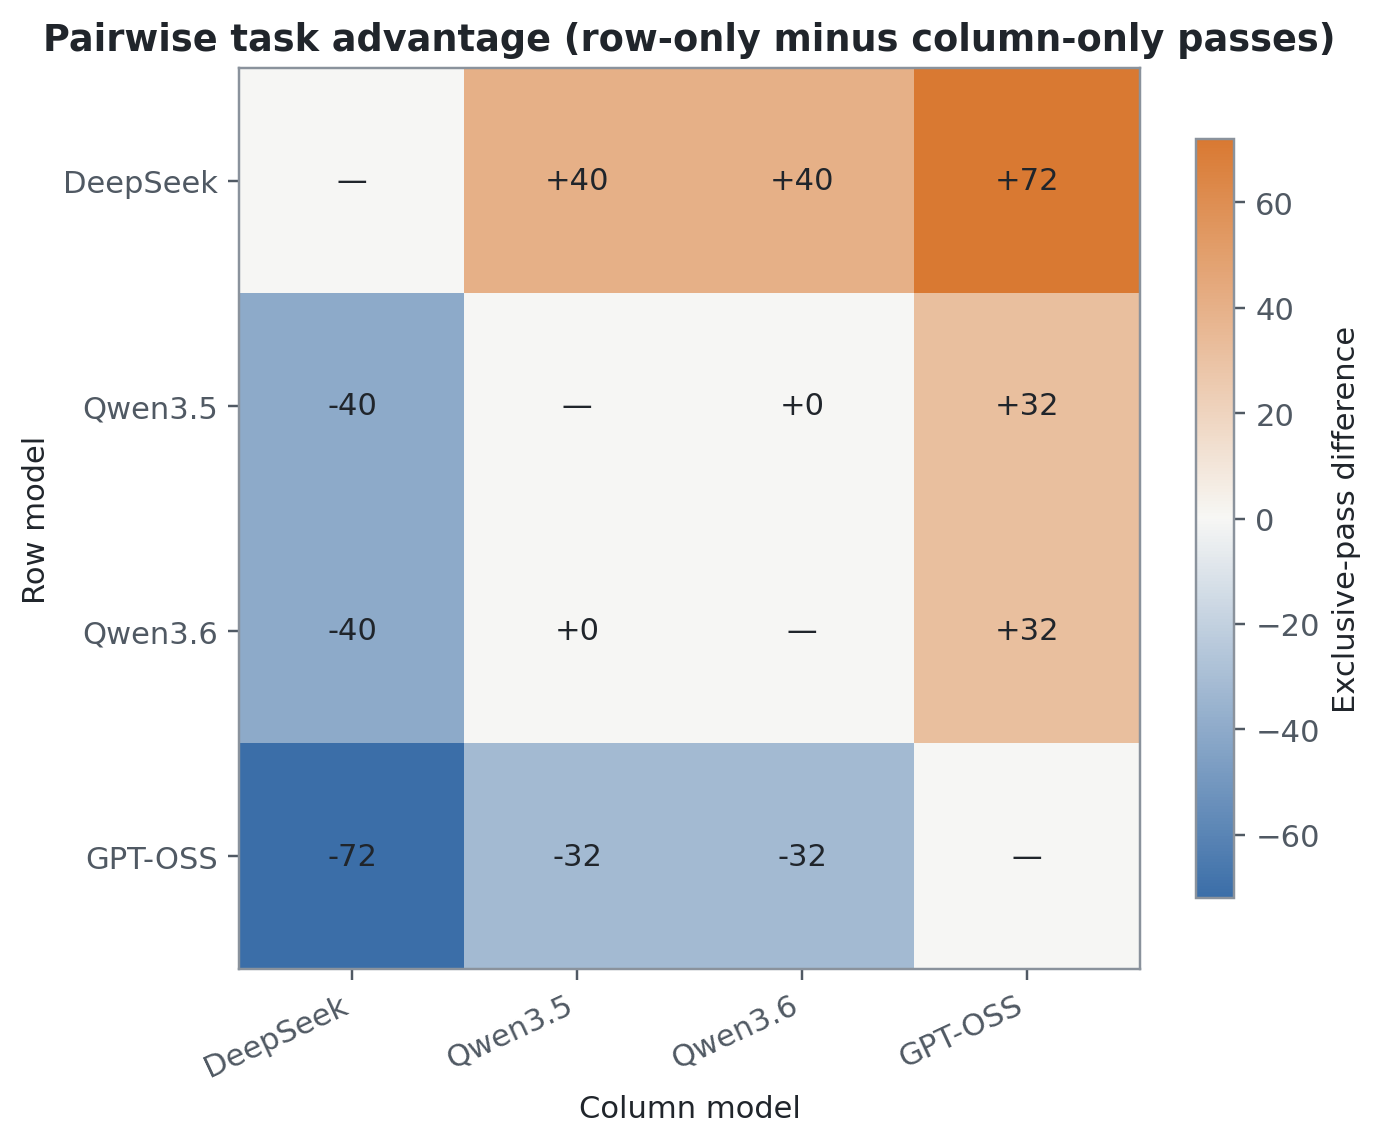

In [4]:
from IPython.display import display, Image
for name in ['fig01_functional_pass_ci','fig02_evaluator_gate_rates','fig03_pairwise_task_advantage']:
    display(Image(filename=str(REPORT_DIR / 'figures' / f'{name}.png'), width=850))

### Task difficulty, efficiency, and compactness

In [5]:
tables['lift_type_summary']

,lift_type,tasks,mean_models_solved,mean_solve_fraction,bootstrap_low,bootstrap_high,median_models_solved
2,Direct,56,2.196429,0.549107,0.473214,0.625000,2.0
0,Adapted,76,1.355263,0.338816,0.269737,0.411184,1.0
1,Composite,18,1.000000,0.250000,0.125000,0.388889,0.0


In [6]:
tables['feature_family_summary']

,feature_family,tasks,mean_models_solved,mean_solve_fraction,bootstrap_low,bootstrap_high,median_models_solved
1,cache_retry_policy,8,2.500000,0.625000,0.375000,0.843750,3.0
4,protocol_state_transition,9,2.111111,0.527778,0.388889,0.666667,2.0
7,serialize_format_render,19,2.052632,0.513158,0.394737,0.631579,2.0
0,algorithm_data_structure,11,2.000000,0.500000,0.295455,0.681818,3.0
3,parse_tokenize_decode,31,1.774194,0.443548,0.330645,0.556452,2.0
9,workflow_session_orchestration,5,1.600000,0.400000,0.100000,0.700000,2.0
2,config_resolve_discover,18,1.388889,0.347222,0.208333,0.486111,1.0
5,registry_plugin_dispatch,22,1.227273,0.306818,0.159091,0.454545,0.5
8,validate_normalize_construct,15,1.133333,0.283333,0.166667,0.416667,1.0
6,resource_metadata_loading,12,1.000000,0.250000,0.083333,0.458333,0.0


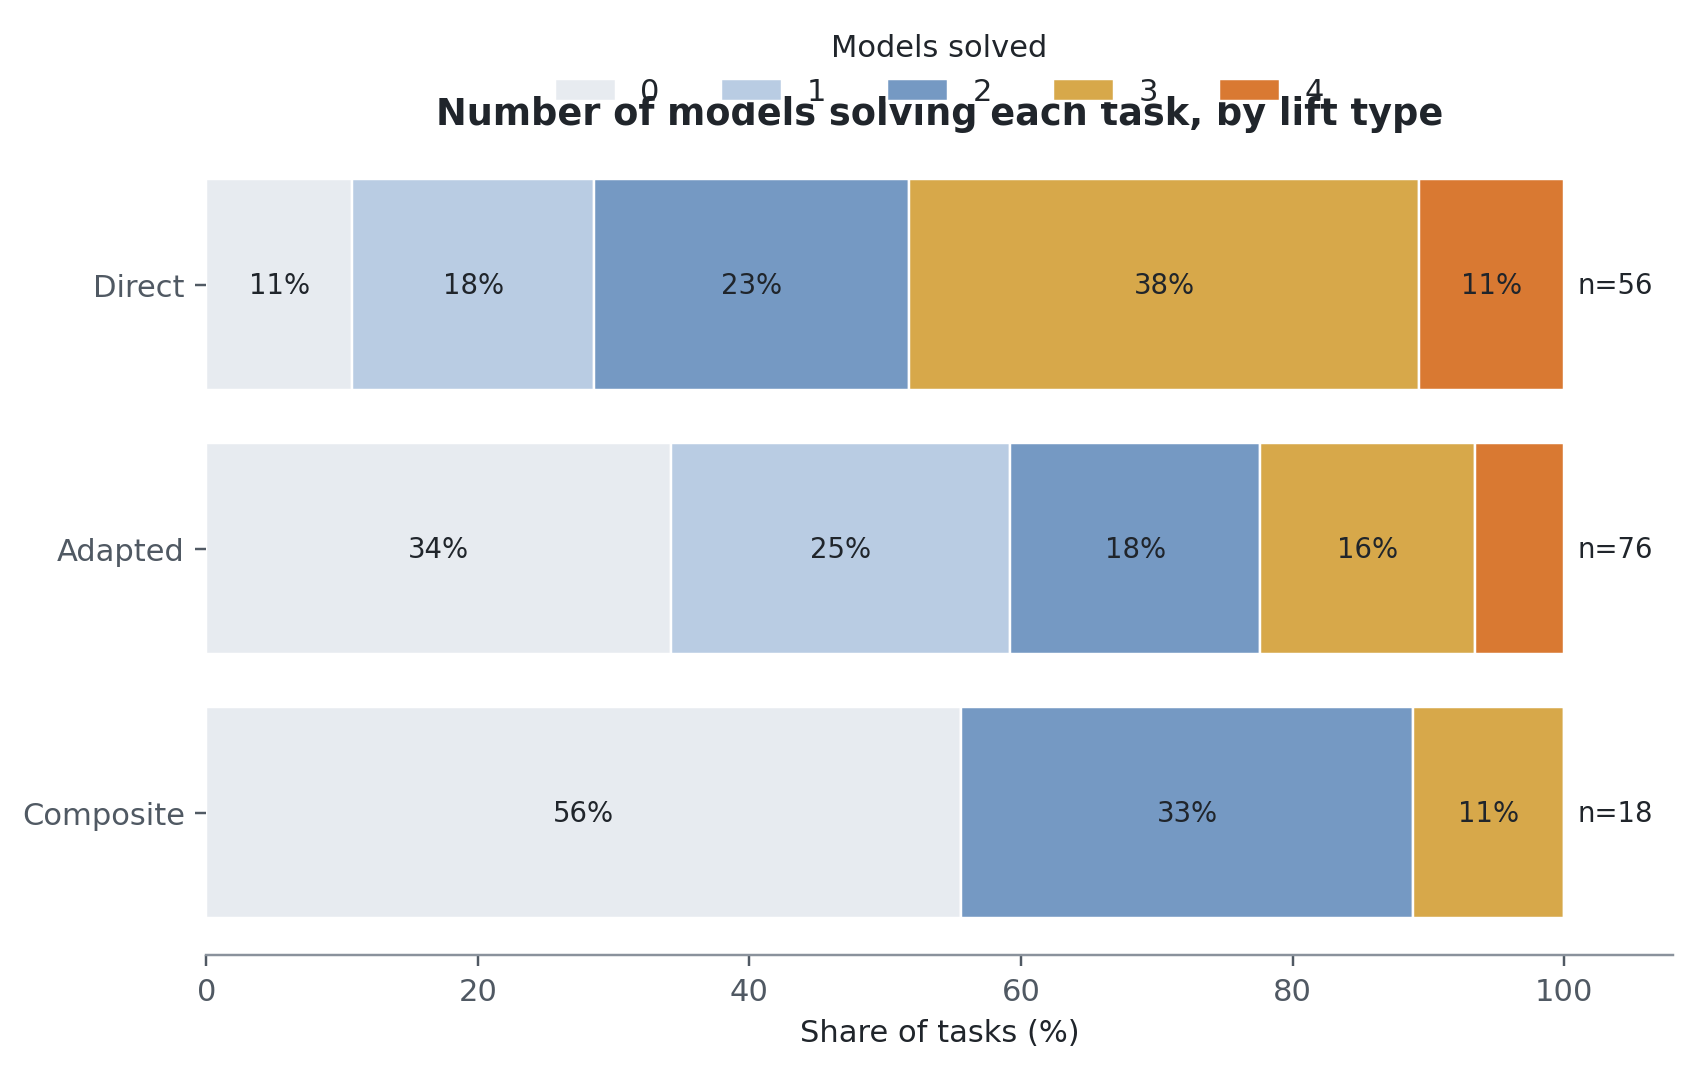

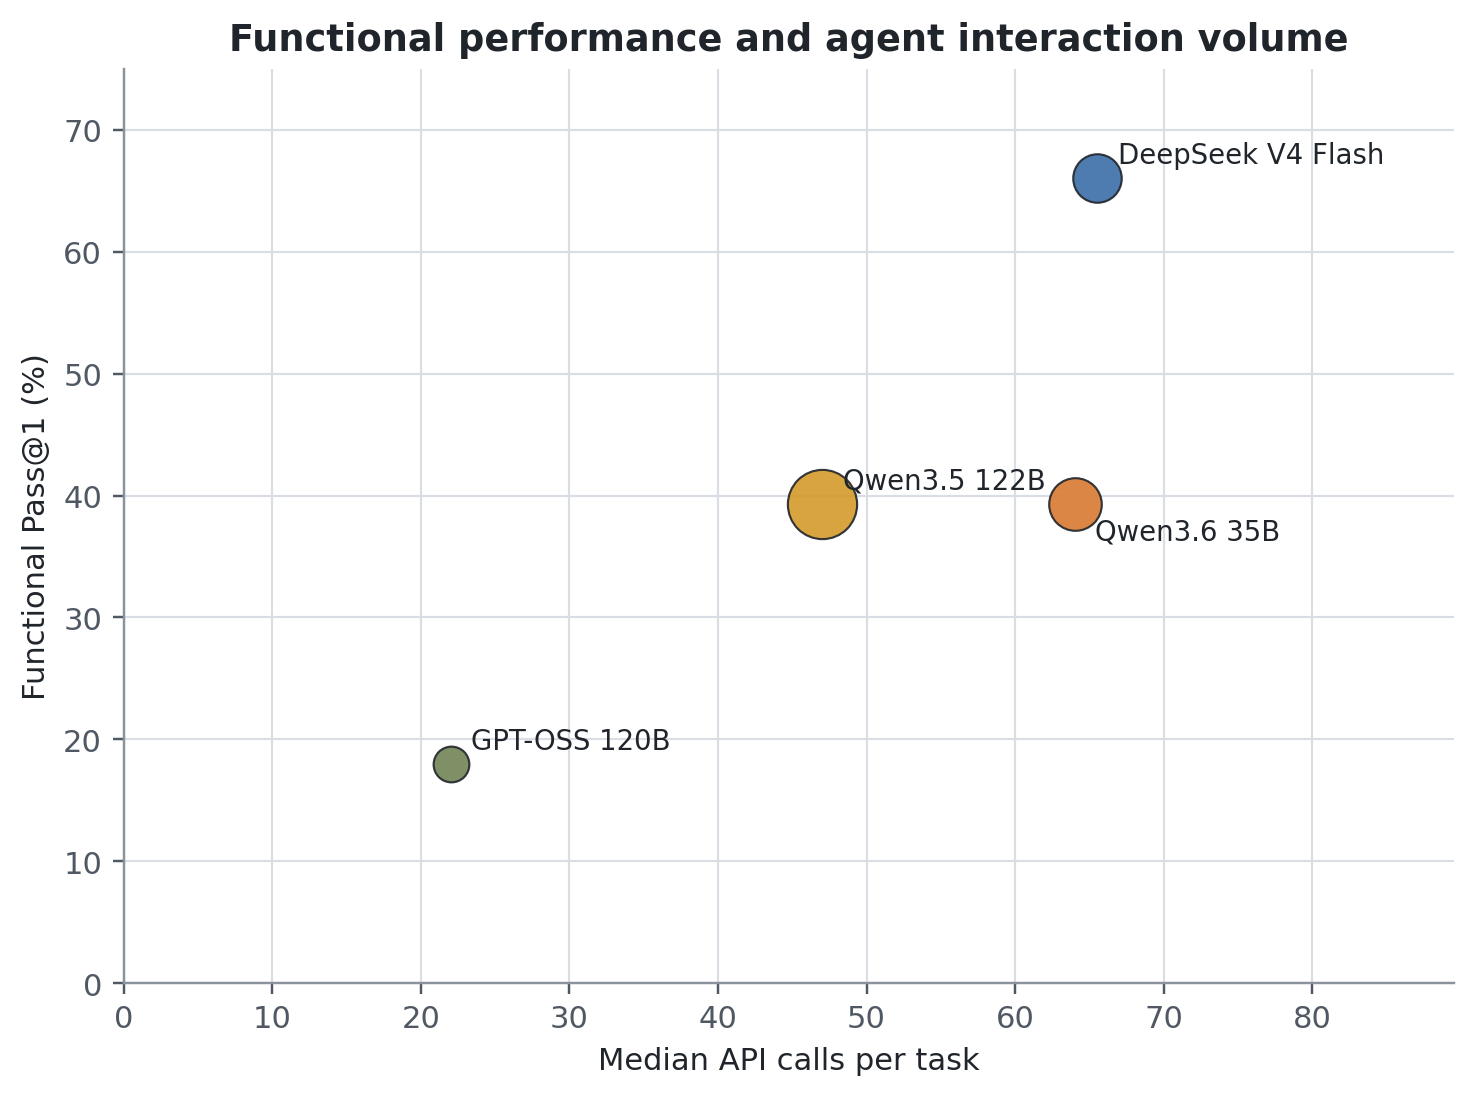

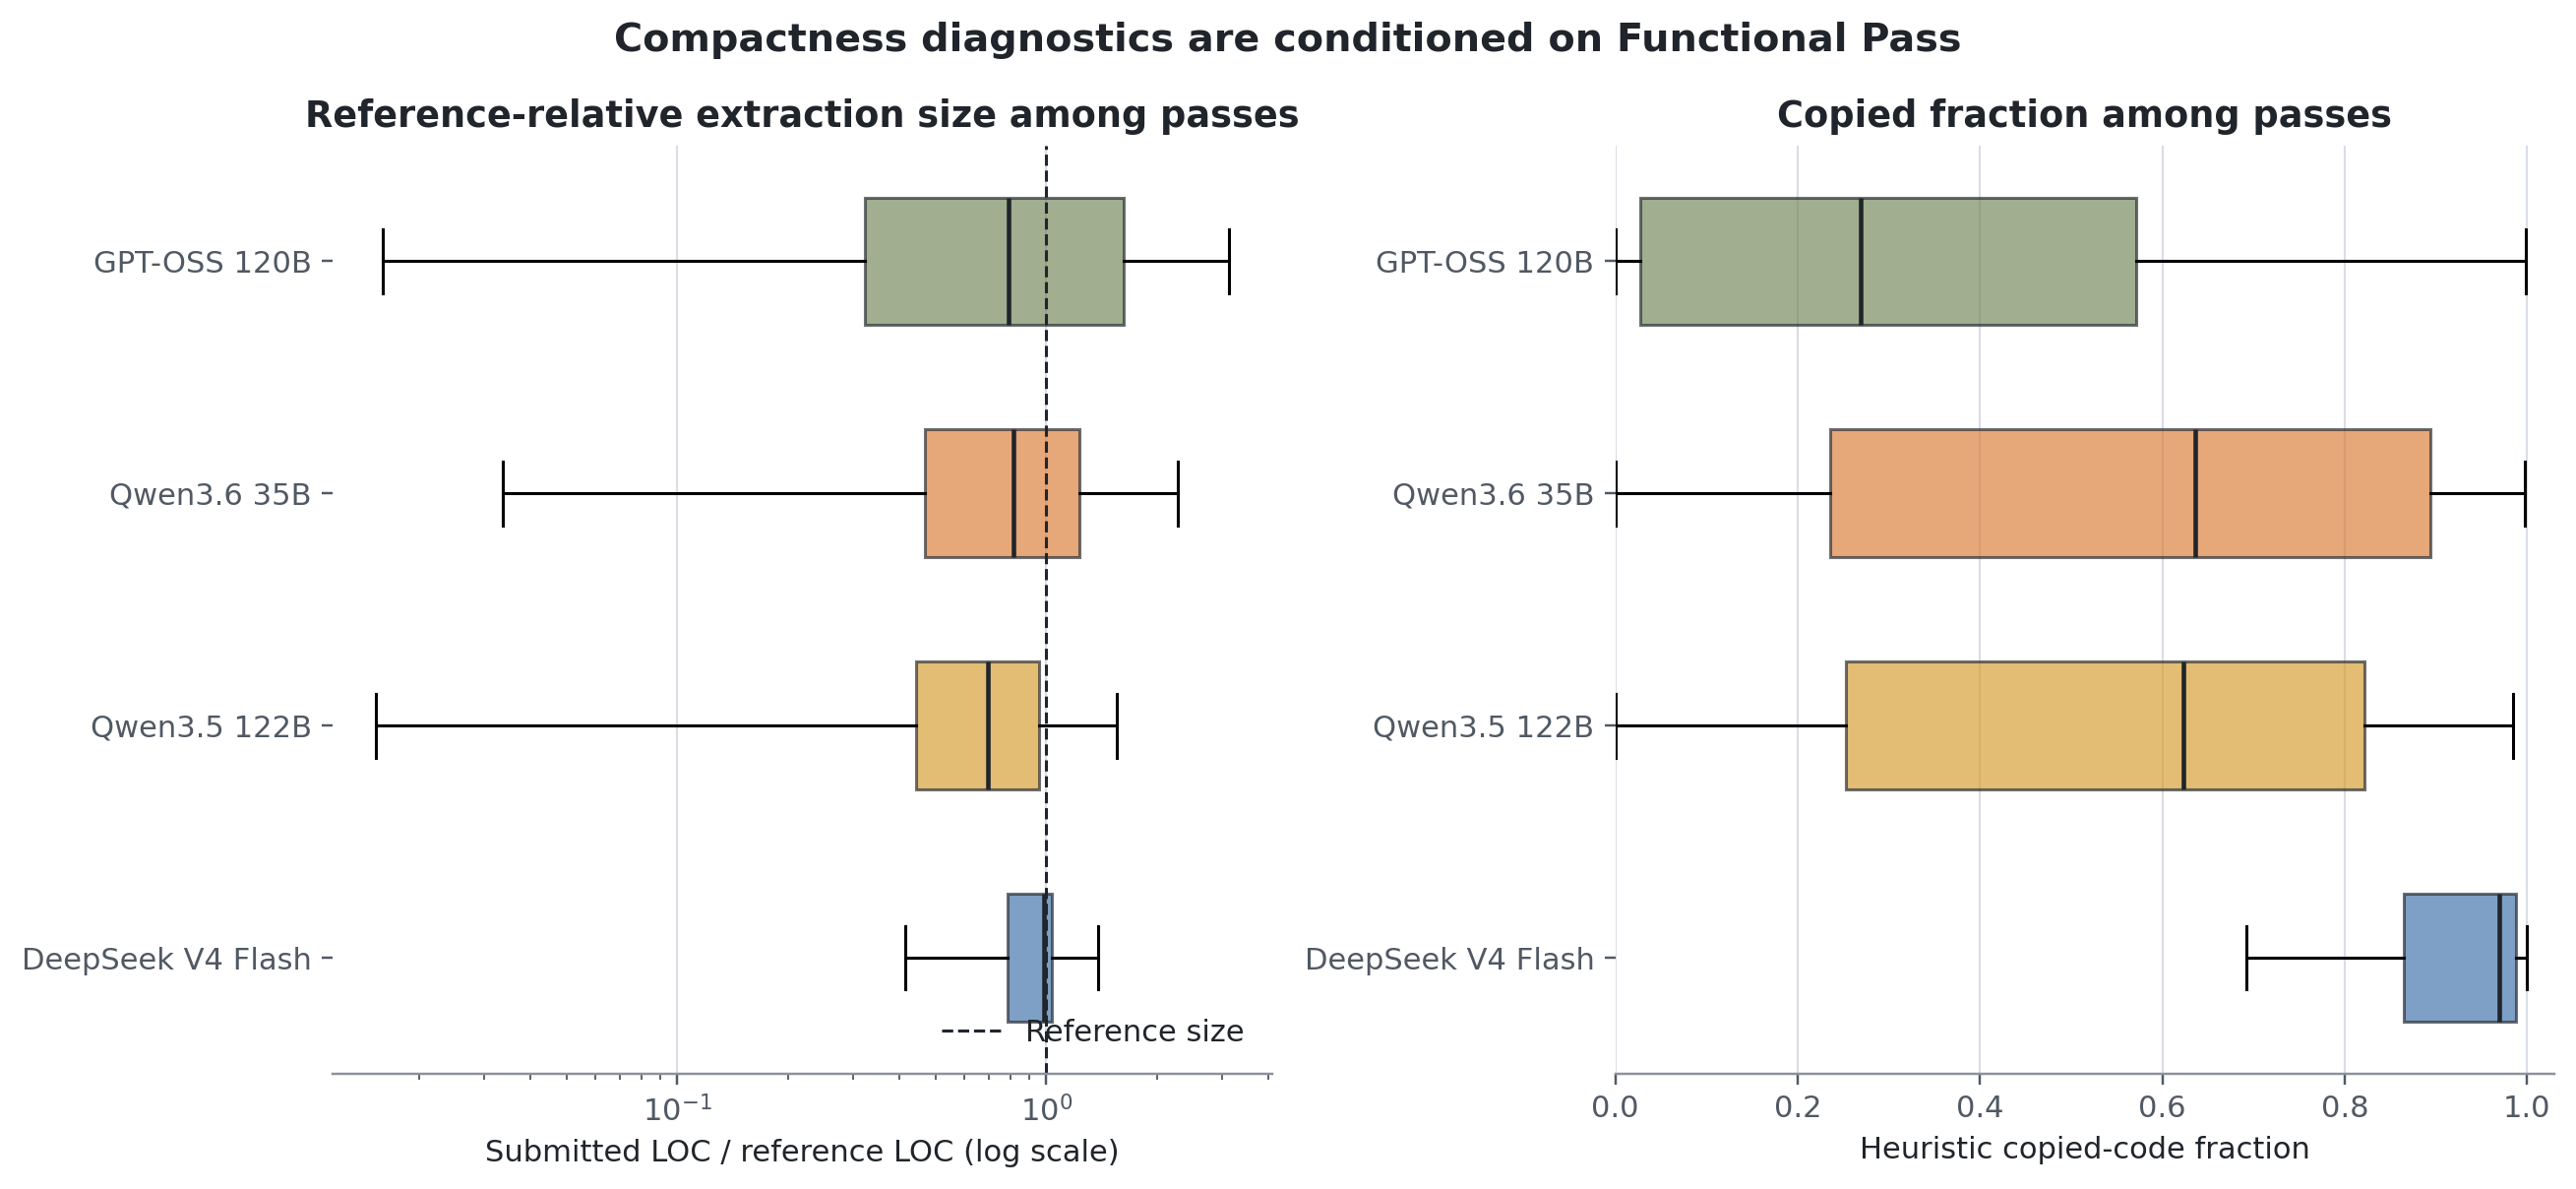

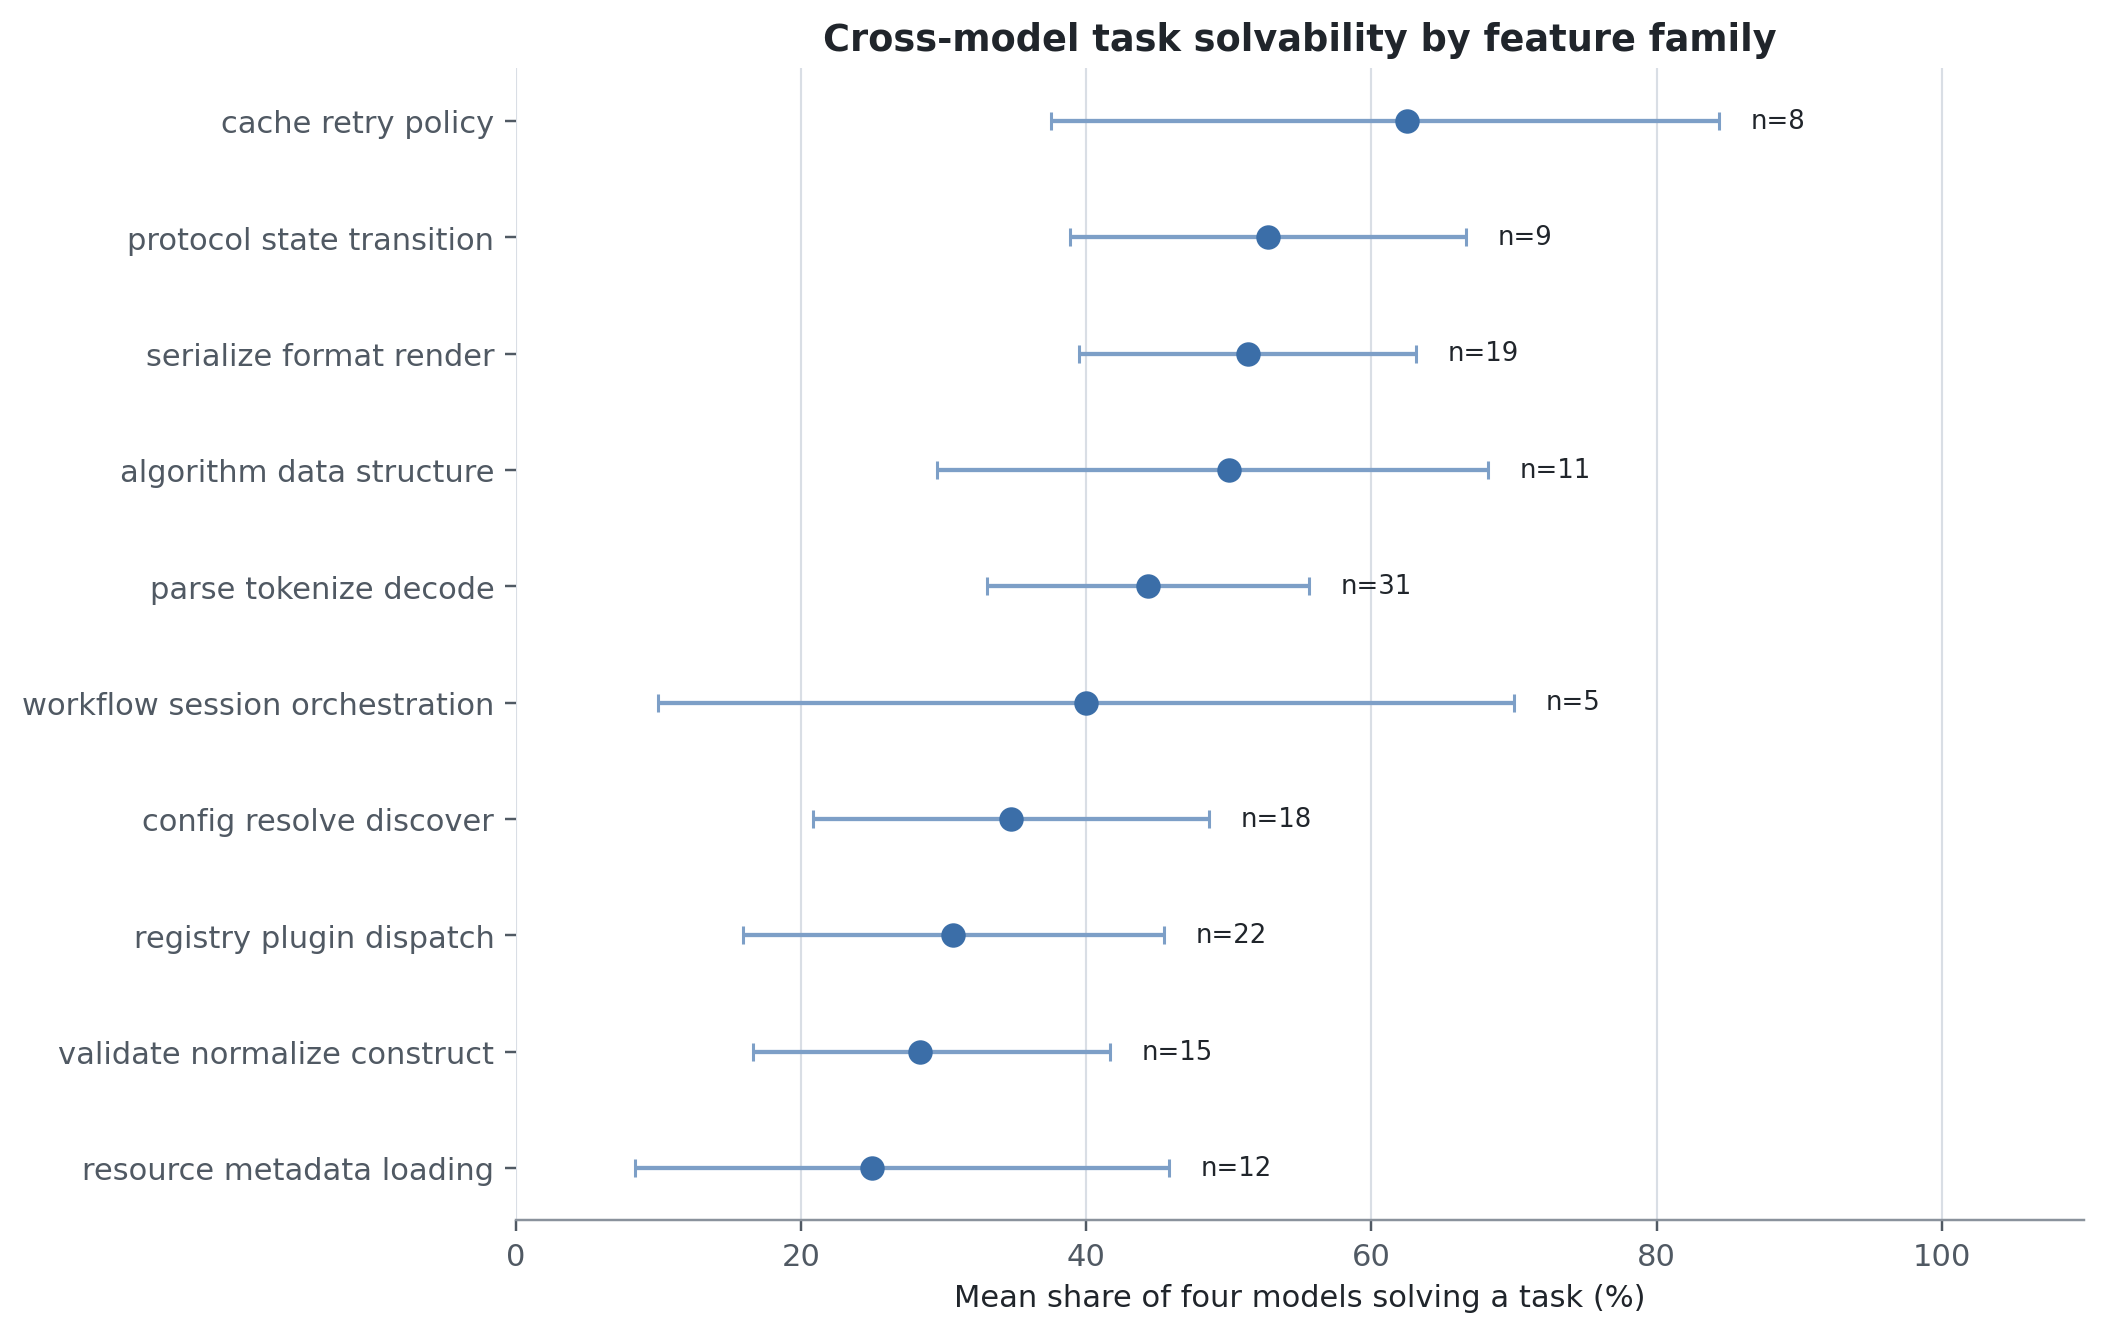

In [7]:
for name in ['fig04_task_solve_count_by_lift','fig05_pass_rate_vs_api_calls','fig06_pass_conditioned_compactness','fig07_feature_family_solvability']:
    display(Image(filename=str(REPORT_DIR / 'figures' / f'{name}.png'), width=900))

## Takeaways

1. Functional capability differs substantially across the four model–runtime configurations.
2. Public and Hidden behavior, not buildability alone, account for most of the separation.
3. Equal aggregate scores can hide substantial task-level complementarity.
4. Direct tasks are more broadly solved than Adapted or Composite tasks in the observed suite.
5. Compactness must be reported after Functional Pass and on paired survivor sets where possible.